In [1]:
import scanpy as sc
import pandas as pd
adata = sc.read_h5ad("baseline.h5ad")
adata

AnnData object with n_obs × n_vars = 5928 × 55737
    obs: 'patient', 'timepoint', 'response', 'therapy', 'patient_raw'
    uns: 'source', 'subset', 'values'

In [ ]:
#each row here is one cell all from the same patient
#this is just the first 5 rows of the data,the full data set has 5928 rows

adata.obs.head()

,patient,timepoint,response,therapy,patient_raw
cell_id,,,,,
A10_P3_M11,P1,baseline,Responder,anti-CTLA4,Pre_P1
A11_P1_M11,P1,baseline,Responder,anti-CTLA4,Pre_P1
A11_P3_M11,P1,baseline,Responder,anti-CTLA4,Pre_P1
A11_P4_M11,P1,baseline,Responder,anti-CTLA4,Pre_P1
A12_P3_M11,P1,baseline,Responder,anti-CTLA4,Pre_P1


In [ ]:
#this counts how many cells are responders and non-responders in the dataset

adata.obs['response'].value_counts()

response
Non-responder    3203
Responder        2725
Name: count, dtype: int64

In [ ]:
#this counts how many cells are in each therapy group

adata.obs['therapy'].value_counts()

therapy
anti-PD1          3795
anti-CTLA4+PD1    1616
anti-CTLA4         517
Name: count, dtype: int64

In [ ]:
#this counts how many cells are responders and non-responders in each therapy group

pd.crosstab(adata.obs['therapy'], adata.obs['response'])

response,Non-responder,Responder
therapy,,
anti-CTLA4,288,229
anti-CTLA4+PD1,311,1305
anti-PD1,2604,1191


In [8]:
#this confrims the number of patients used in this dataset

adata.obs['patient'].nunique()

19

In [ ]:
#this shows each patient and how many cells they each contributed

adata.obs['patient'].value_counts()

patient
P33    452
P25    371
P7     368
P31    351
P27    343
P24    338
P28    337
P2     337
P26    333
P12    330
P20    323
P4     311
P15    304
P6     288
P8     267
P3     245
P35    238
P1     229
P29    163
Name: count, dtype: int64

In [ ]:
# one row per patient, with their therapy and response

#after running i can see there is an uneven distribution of patients across therapy and response groups, which may affect the analysis.

patient_info = adata.obs[['patient', 'therapy', 'response']].drop_duplicates()
pd.crosstab(patient_info['therapy'], patient_info['response'])

response,Non-responder,Responder
therapy,,
anti-CTLA4,1,1
anti-CTLA4+PD1,1,4
anti-PD1,8,4


In [12]:
#flagging the mitochondrial genes

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["mt"].sum()

np.int64(37)

In [ ]:
#computing the QC (quality control) metrics


sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)

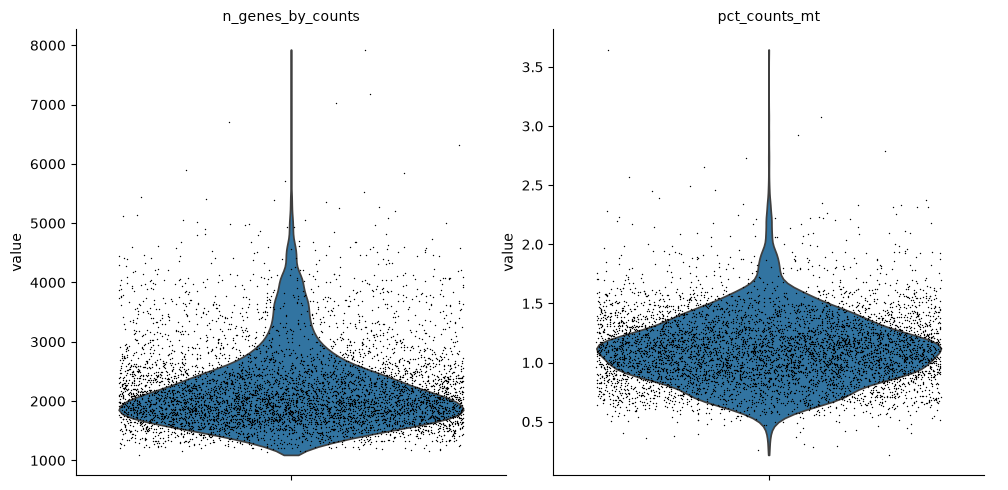

In [ ]:
# distribution of genes-per-cell and mito %

#Violin 1 (left) shows a median of about 2000 genes per cell
#the cells range from about 1000-8000, this shows the data is already well filtered as there is nothing at end towards 0

#Violin 2 (right) shows a median of 1.1-1.2% mitochondrial genes per cell
#which is a good sign as it indicates that the cells are healthy and not stressed or dying.

#for both each dot is a cell

sc.pl.violin(adata, ['n_genes_by_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

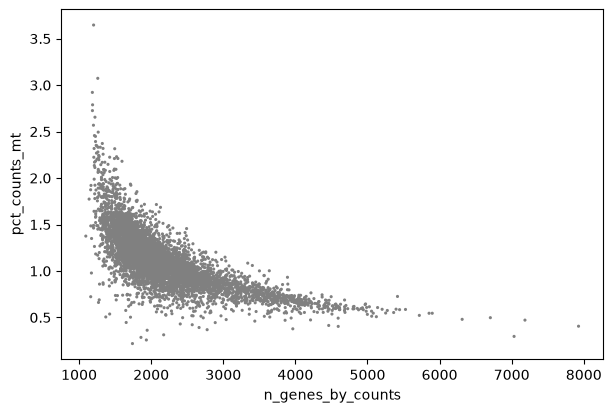

In [ ]:
# how the two relate, per cell

#this shows a negative correlation between the number of genes detected and the percentage of mitochondrial genes
#which is expected as stressed or dying cells tend to have fewer genes detected and a higher proportion of mitochondrial genes.

sc.pl.scatter(adata, x='n_genes_by_counts', y='pct_counts_mt')

In [16]:
#justification for filtering thresholds
#min genes = 1,000 — from the violin and scatter, the main body of cells sits above ~1,000 genes; 
#below that you're into the sparse tail where cells also show elevated mito %. That's the poor-quality corner.
#max mito = 3% — nearly every cell sits under 2%; only a handful of stragglers reach up toward 3.6%. 
#A 3% ceiling trims just those extreme few without touching the healthy bulk.

# how many cells fall below / above each threshold?
print("cells with < 1000 genes:", (adata.obs['n_genes_by_counts'] < 1000).sum())
print("cells with > 3% mito:   ", (adata.obs['pct_counts_mt'] > 3).sum())
print("total cells now:        ", adata.n_obs)

cells with < 1000 genes: 0
cells with > 3% mito:    2
total cells now:         5928


In [17]:
# minimum genes per cell
sc.pp.filter_cells(adata, min_genes=1000)

# maximum mitochondrial %  (boolean mask, as her sheet describes)
adata = adata[adata.obs['pct_counts_mt'] < 3].copy()

adata

AnnData object with n_obs × n_vars = 5926 × 55737
    obs: 'patient', 'timepoint', 'response', 'therapy', 'patient_raw', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'source', 'subset', 'values'

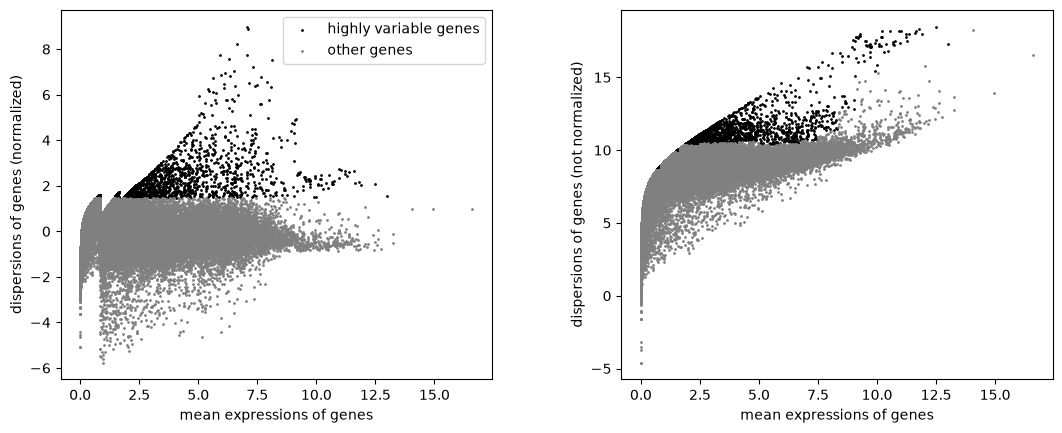

In [18]:
#this picks out the genes woth keeping
#we want genes that vary a lot beteween cells 
#2nd line of code plots the results

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
sc.pl.highly_variable_genes(adata)

c:\Users\zoehe\miniconda3\envs\zoe-sc\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


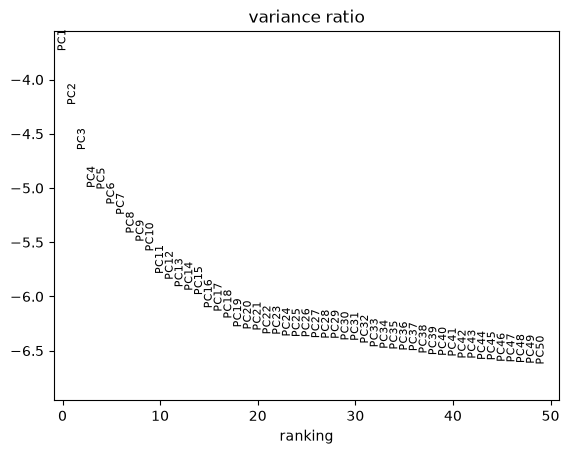

In [19]:
adata.raw = adata          # full-gene copy for later marker plots
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

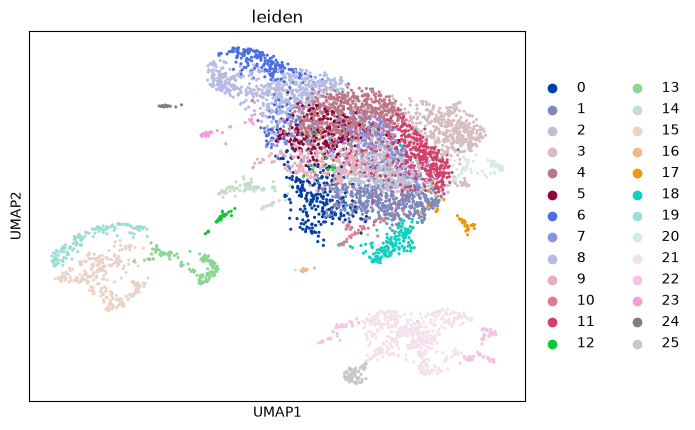

In [ ]:
#leiden clustering

#The big blob in the middle-right — lots of clusters (0, 1, 2, 3, 5, 11...) 
#crowded together and blending into each other. 
#When cells sit close like this, they're biologically similar. 
#Given this is a T-cell-heavy melanoma dataset, that mass is very likely a bunch of related T-cell states shading into one another.
#The islands off to the left and bottom (19, 20, 14, 22...) — clearly separated blobs mean distinctly different cell types. 
#These are probably things like B cells or monocytes: genuinely different from T cells, so they land far away.

sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata, color='leiden')

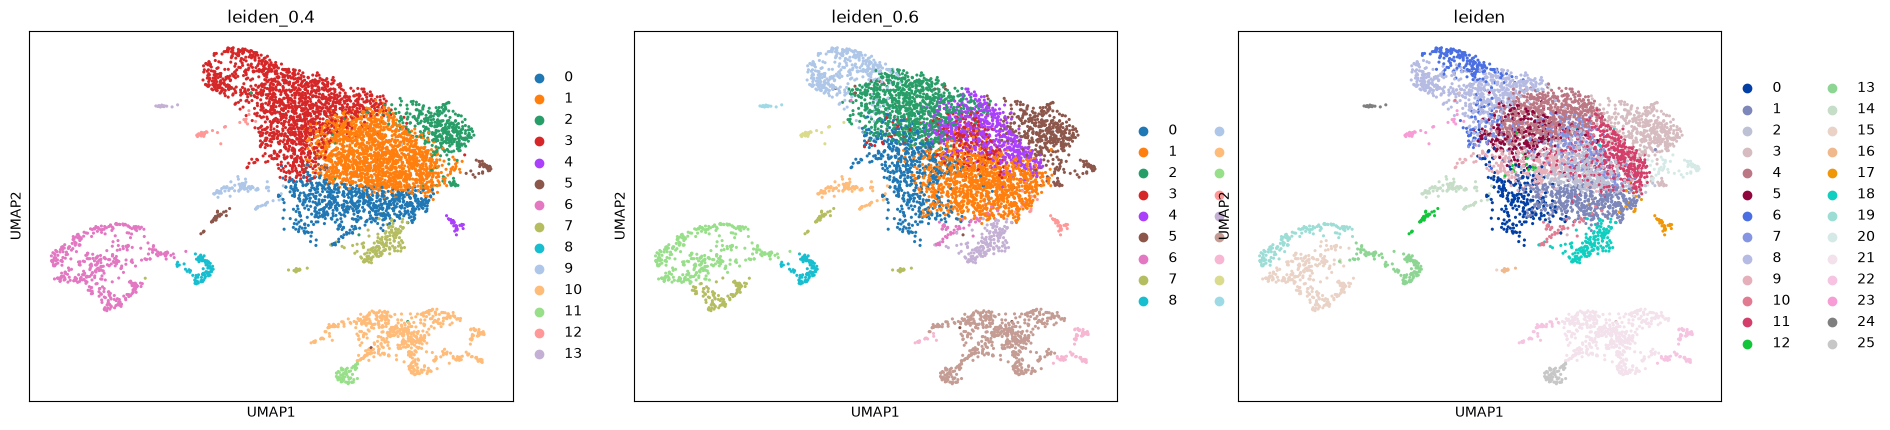

In [21]:
#trying that again with a lower resolution because i got more groups that the doc expected

sc.tl.leiden(adata, resolution=0.4, key_added="leiden_0.4", flavor="igraph", n_iterations=2, directed=False)
sc.tl.leiden(adata, resolution=0.6, key_added="leiden_0.6", flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata, color=['leiden_0.4', 'leiden_0.6', 'leiden'])

In [22]:
#renaming the far right plot so it makes sence 
adata.obs['leiden_1.0'] = adata.obs['leiden']

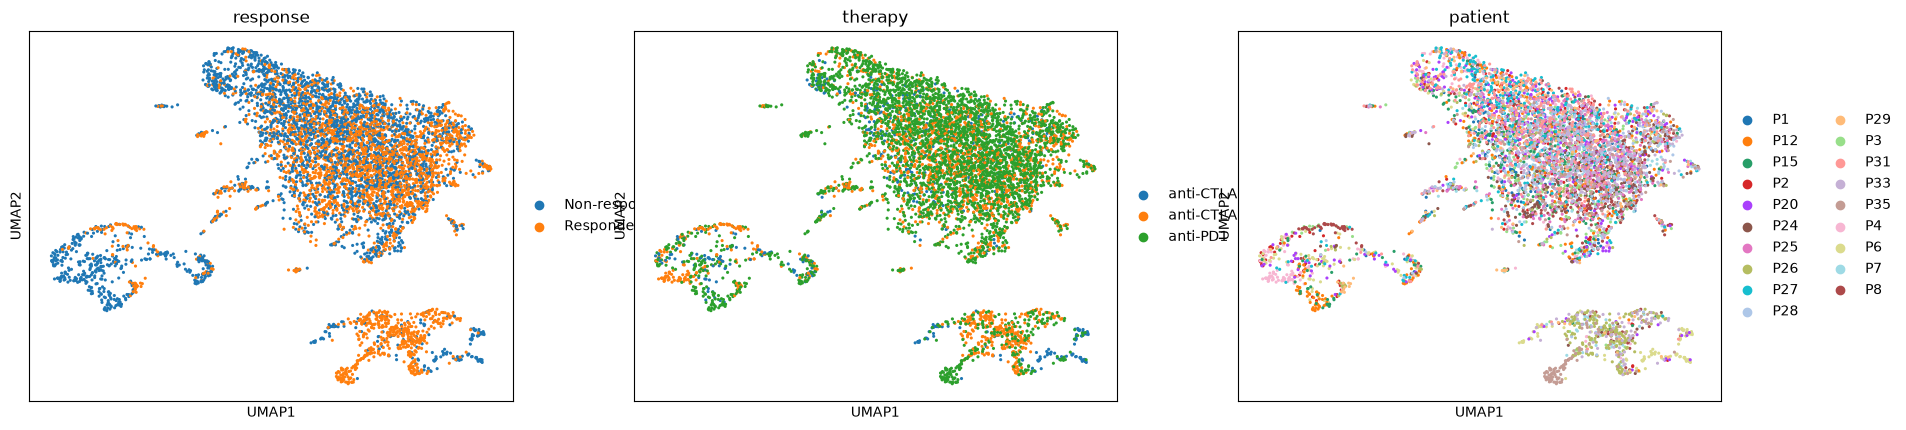

In [ ]:
#bringing in the metadata 

#this connects the clusters back to the patients 

sc.pl.umap(adata, color=['response', 'therapy', 'patient'])

In [24]:
#this is to quantify it

pd.crosstab(adata.obs['leiden_0.4'], adata.obs['response'], normalize="index")

response,Non-responder,Responder
leiden_0.4,,
0,0.447293,0.552707
1,0.466976,0.533024
2,0.452575,0.547425
3,0.701654,0.298346
4,0.500000,0.500000
5,0.383562,0.616438
6,0.825175,0.174825
7,0.602410,0.397590
8,0.841463,0.158537


In [ ]:
#the first row shows that one patient contributes 98% of that clusters cells.
#this should be dicsrded as because its missleading: its not that reponders have more of this cell state, its thato ne responder contributed almost al of it
#everything else looks healthy
#im not dicarding it yet because instructions were to wait unitll supervisor meeting

pt = pd.crosstab(adata.obs['leiden_0.4'], adata.obs['patient'], normalize="index")
pt.max(axis=1).sort_values(ascending=False)

leiden_0.4
11    0.983607
10    0.331010
6     0.228438
8     0.207317
12    0.176471
4     0.166667
9     0.152174
5     0.136986
13    0.125000
0     0.122507
7     0.120482
3     0.119593
2     0.116531
1     0.115875
dtype: float64

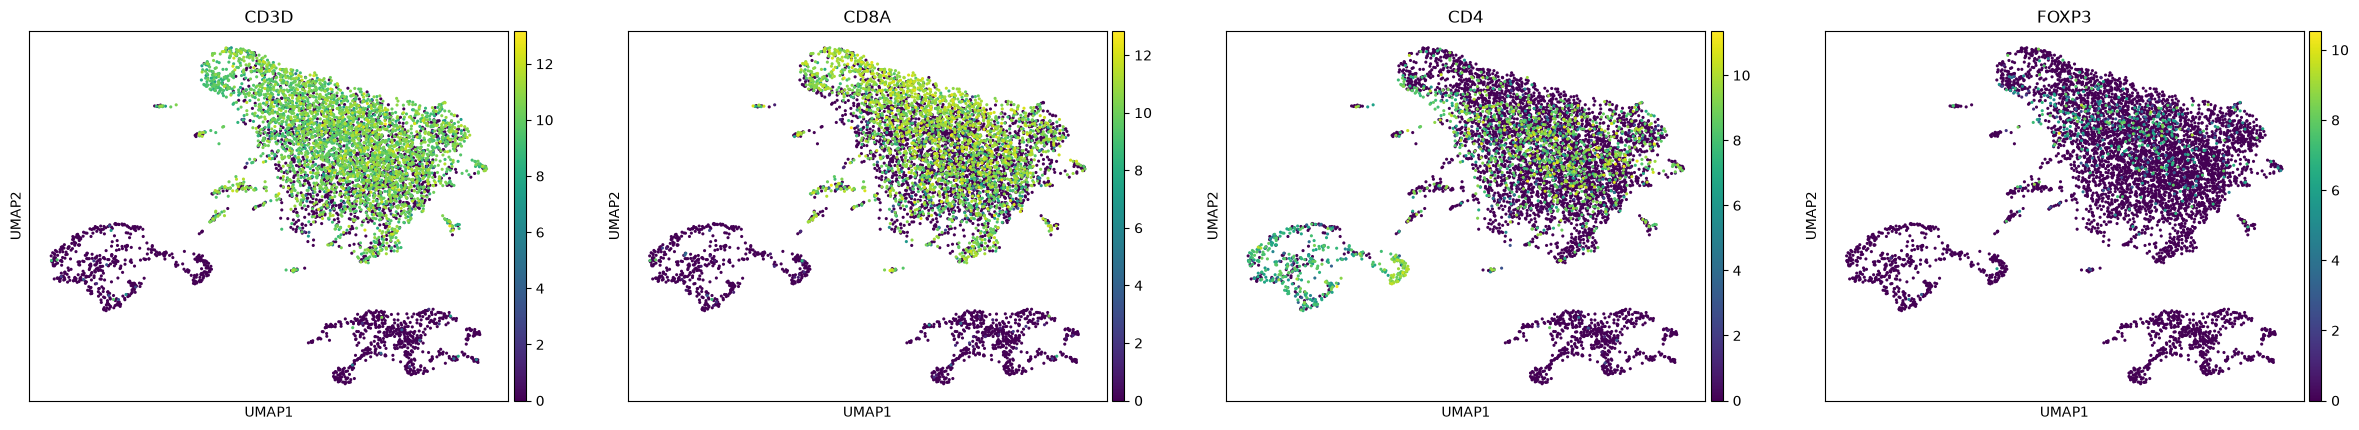

In [ ]:
#each graph here is a gene and the color shows how much of that gene is expressed in each cell.

sc.pl.umap(adata, color=['CD3D', 'CD8A', 'CD4', 'FOXP3'], use_raw=True)

In [27]:
#saving progress 

adata.write("baseline_clustered.h5ad")